In [1]:
import sys, os, gc
sys.path.insert(0, os.path.join('..'))   # project root on path

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wrds
import polars as pl
import polars.selectors as cs
import pyarrow
import config

from src.utils import generate_batches, train_val_test_split, split_batch
from sklearn.metrics import root_mean_squared_error, r2_score
from src.data_loading import *

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)

---
# Fetch S&P500 data for benchmark

In [83]:
# df_sp500 = fetch_sp500()
gspc = pd.read_parquet(config.GSPC_PATH_RAW)
gspc = gspc.dropna()
gspc['date'] = pd.to_datetime(gspc['date'])
gspc = gspc.drop(['vwretd', 'ewretd'], axis=1).reset_index(drop=True)
gspc.to_parquet(config.GSPC_PATH_CLEAN)
gspc.head()

,date,sprtrn
0,1962-07-03,0.0113
1,1962-07-05,0.0057
2,1962-07-06,-0.0113
3,1962-07-09,0.0068
4,1962-07-10,0.0115


In [103]:
gspc.iloc[13214 : 13215]

,date,sprtrn
13214,2014-12-31,-0.0103


In [126]:
def buy_and_hold(
    df: pd.DataFrame, 
    initial_capital: float = 1.0,
    start_date=None,
    end_date=None
) -> pd.DataFrame:
        
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    mask = (df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))
    filtered = df.loc[mask, ['date', 'sprtrn']].reset_index(drop=True)
    
    anchor_date = pd.to_datetime(start_date) - pd.tseries.offsets.BDay(1)
    initial_row = pd.DataFrame({'date': [anchor_date], 'sprtrn': [0.0]})
    result = pd.concat([initial_row, filtered], ignore_index=True)
    
    pf = (result['sprtrn'] + 1).cumprod() * initial_capital
    date = result['date']
    
    return pf, date

---
# Generate Batch and Merge

Generating the random sampled batch and merging the other dataset on the batch. 

We merge other dataset with the daily dataset only at the batch level in order to largely decrease the RAM usage duriung the operation considering the size of the daily dataframe with around 6700 stocks.

In [8]:
"""

Read the features.parquet file and make the batch/split of the data

"""

features = pd.read_parquet(config.FEATURES_PATH_CLEAN).dropna()
cz = pd.read_parquet(config.CZ_PATH_CLEAN)
vix = pd.read_parquet(config.VIX_PATH_CLEAN)

# 1. Merge VIX with CZ
df_tmp = pd.merge(cz, vix, on='date')

print(f'Number of unique PERMNO in dataset : {features['PERMNO'].nunique()}')

split_batch_dict = split_batch(features, 'PERMNO', 'date', df_to_join=[df_tmp], batch_number=config.BATCH_NUMBER, batch_size=config.BATCH_SIZE, overlap=False)

del features, cz, vix, df_tmp
gc.collect()

Number of unique PERMNO in dataset : 6647
Total unique dates: 5103
  train: 2000-10-17 → 2014-12-30  (3572 dates, 70.0%)
  val  : 2014-12-31 → 2018-01-12  (765 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5103
  train: 2000-10-17 → 2014-12-30  (3572 dates, 70.0%)
  val  : 2014-12-31 → 2018-01-12  (765 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5103
  train: 2000-10-17 → 2014-12-30  (3572 dates, 70.0%)
  val  : 2014-12-31 → 2018-01-12  (765 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5104
  train: 2000-10-16 → 2014-12-29  (3572 dates, 70.0%)
  val  : 2014-12-30 → 2018-01-12  (766 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5104
  train: 2000-10-16 → 2014-12-29  (3572 dates, 70.0%)
  val  : 2014-12-30 → 2018-01-12  (766 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)


26

In [10]:
""""

Unique batch test

"""
from sklearn.linear_model import LassoCV, Lasso, lasso_path


# 1. Set training and validation set
TARGET = 'target'

y_train = split_batch_dict['batch_1']['train'][TARGET]
X_train = split_batch_dict['batch_1']['train'].drop([TARGET, 'ret', 'mkt_ret'], axis=1)

y_val = split_batch_dict['batch_1']['validation'][TARGET]
X_val = split_batch_dict['batch_1']['validation'].drop([TARGET, 'ret', 'mkt_ret'], axis=1)


# 2. Trouver alpha sur un échantillon représentatif
sample_idx = np.random.choice(len(X_train), size=50_000, replace=False)
cv_model = LassoCV(cv=5, n_jobs=1)
cv_model.fit(X_train.iloc[sample_idx], y_train.iloc[sample_idx])

best_alpha = cv_model.alpha_
print(f"Alpha optimal : {best_alpha:.6f}")

model = Lasso(alpha=best_alpha)
model.fit(X_train, y_train)

print(f"R² train : {r2_score(y_train, model.predict(X_train)):.4f}")
print(f"R² val   : {r2_score(y_val, model.predict(X_val)):.4f}")


Alpha optimal : 0.000003
R² train : 0.0015
R² val   : -0.0001


In [28]:
y_pred = model.predict(X_val)
y_pred = pd.DataFrame(y_pred, columns=['ret_pred'] ,index=y_val.index)
y_pred.head()

ret_pred
date       PERMNO          
2014-12-31 72980    -0.0001
           75887     0.0006
           72726     0.0003
           78018     0.0009
           59185    -0.0003

In [29]:
percentile_ranks = y_pred.groupby('date')['ret_pred'].transform(lambda x: x.rank(pct=True))

is_top_20 = percentile_ranks >= 0.80
is_bottom_20 = percentile_ranks <= 0.20

top_20_indexes = y_pred[is_top_20].index
bottom_20_indexes = y_pred[is_bottom_20].index

top_20_val_rows = pd.DataFrame(y_val.loc[top_20_indexes])
bottom_20_val_rows = pd.DataFrame(y_val.loc[bottom_20_indexes])

top_20 = top_20_val_rows.groupby('date').mean()
bottom_20 = bottom_20_val_rows.groupby('date').mean()
top_bottom = top_20 - bottom_20

In [137]:
# ── Paramètres ────────────────────────────────────────────────────────────────
N                  = 1_000   # Capital initial
LONG_WEIGHT        = 0.50    # 50% long sur top 20%
SHORT_WEIGHT       = 0.10    # 10% short sur bottom 20%
TRADING_COST       = 0.001    # frais de transaction
BORROW_COST_ANNUAL = 0.01    # 1% coût d'emprunt annuel sur le short leg
TRADING_DAYS       = 252

# ── PnL journalier (vectorisé) ────────────────────────────────────────────────
# Short PnL = -weight * return  (on gagne quand le titre baisse)
daily_borrow_cost = SHORT_WEIGHT * (BORROW_COST_ANNUAL / TRADING_DAYS)
daily_trading_cost = (LONG_WEIGHT + SHORT_WEIGHT) * 2 * TRADING_COST

daily_returns_pct = (
      LONG_WEIGHT  * (top_20 - TRADING_COST).squeeze()       # .squeeze() force en 1D si DataFrame à 1 colonne
    - SHORT_WEIGHT * (bottom_20 - TRADING_COST).squeeze()
    - daily_borrow_cost
    - daily_trading_cost
).reset_index(drop=True)                    # index propre 0, 1, 2, ...

# ── Évolution du portefeuille (100% pandas, pas de numpy) ─────────────────────
portfolio = pd.concat(
    [pd.Series([N]), N * (1 + daily_returns_pct).cumprod()],
    ignore_index=True
)

# ── Métriques de performance ──────────────────────────────────────────────────
total_return   = portfolio.iloc[-1] / N - 1
annualized_ret = (1 + total_return) ** (TRADING_DAYS / len(daily_returns_pct)) - 1
volatility     = daily_returns_pct.std() * np.sqrt(TRADING_DAYS)
sharpe         = annualized_ret / volatility
drawdown       = (portfolio / portfolio.cummax()) - 1
max_drawdown   = drawdown.min()

print(f"Rendement total      : {total_return:+.2%}")
print(f"Rendement annualisé  : {annualized_ret:+.2%}")
print(f"Volatilité annualisée: {volatility:.2%}")
print(f"Sharpe Ratio         : {sharpe:.2f}")
print(f"Max Drawdown         : {max_drawdown:.2%}")


Rendement total      : -61.88%
Rendement annualisé  : -27.25%
Volatilité annualisée: 9.18%
Sharpe Ratio         : -2.97
Max Drawdown         : -62.07%


In [133]:
BH, date_range = buy_and_hold(gspc, initial_capital=N, start_date=y_pred.index.min()[0], end_date=y_pred.index.max()[0])

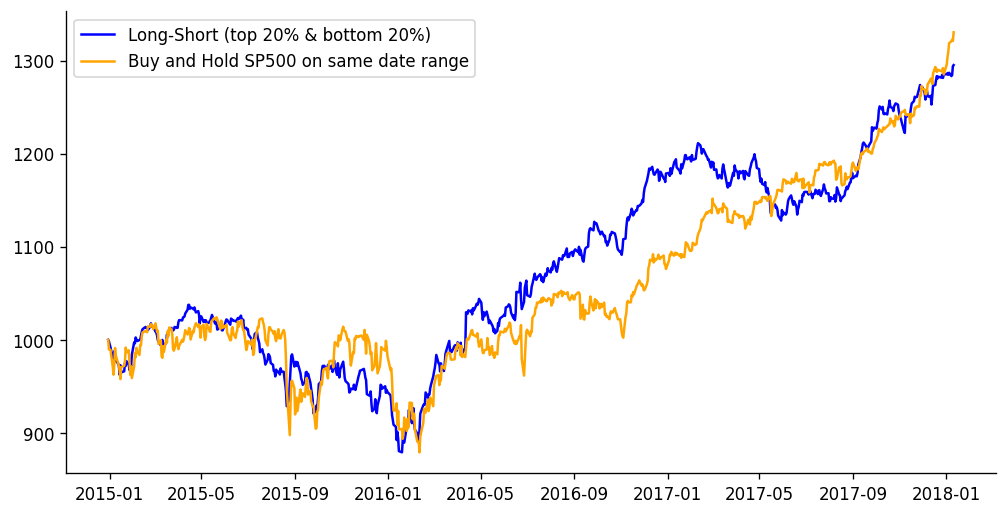

In [136]:
plt.figure(figsize=(10,5))
plt.plot(date_range, portfolio, color='blue', label='Long-Short (top 20% & bottom 20%)')
plt.plot(date_range, BH, color='orange', label='Buy and Hold SP500 on same date range') 
plt.legend()
plt.show()